In [5]:
import numpy as np
import torch
import os
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn as nn

In [6]:
#mount google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [24]:
data_dir = "/content/gdrive/My Drive/APS360/APS360_project/ProcessedInputData"

X_train = np.load(data_dir + '/X_train_seq.npy')
Y_train = np.load(data_dir + '/y_train_seq.npy')
X_val = np.load(data_dir + '/X_val_seq.npy')
Y_val = np.load(data_dir + '/y_val_seq.npy')
X_test = np.load(data_dir + '/X_test_seq.npy')
Y_test = np.load(data_dir + '/y_test_seq.npy')

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

# Create a DataLoader for batching
batch_size = 128
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # don't shuffle for LTSM?
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)  # Xavier initialization
        if m.bias is not None:
            nn.init.zeros_(m.bias)  # Initialize biases to zero

In [20]:
import torch
import torch.nn as nn

class TakeNet(nn.Module):
    def __init__(self, hidden_size1, num_layers):
        super(TakeNet, self).__init__()

        # CNN Block
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1),
            #nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=2),
            #nn.Dropout(0.1),

            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            #nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=2),
            #nn.Dropout(0.1)
        )

        # Compute CNN output size dynamically
        self._to_linear = self._compute_linear_input_size()

        # LSTM Layers
        self.lstm1 = nn.LSTM(input_size=self._to_linear, hidden_size=hidden_size1, num_layers=num_layers, batch_first=True)
        self.lstm_norm = nn.LayerNorm(hidden_size1)

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_size1, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),#0.3 #0.4
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),#0.2 #0.1 - 60%
            nn.Linear(64, 1)  # Output layer
        )

    def _compute_linear_input_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, 5, 90)  # Dummy input
            x = self.cnn(x)
            x = x.permute(0, 2, 1, 3).contiguous()  # (batch, time_steps, channels, features)
            x = x.view(x.size(0), x.size(1), -1)  # Flatten last two dimensions
            return x.shape[2]  # Feature size per timestep

    def forward(self, x):
        x = x.view(-1, 1, 5, 90)  # Ensure correct shape

        # Pass through CNN
        x = self.cnn(x)

        # Reshape for LSTM
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(x.size(0), x.size(1), -1)  # (batch, time_steps, features)

        # Pass through LSTM layers
        x, _ = self.lstm1(x)
        x = self.lstm_norm(x)

        x = x[:, -1, :]  # Last time step's output

        # Fully Connected Output
        x = self.fc(x)

        return x  # No activation (for regression tasks)


In [3]:
import time
import matplotlib.pyplot as plt
import sys


def get_accuracy(model, data):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():  # No need to track gradients
        for inputs, labels in data:
            outputs = model(inputs)  # Forward pass
            predictions = torch.round(torch.sigmoid(outputs))
            labels = labels.view(-1, 1).float()
            correct += (predictions == labels).sum().item()  # Count correct predictions
            total += labels.size(0)  # Total number of samples

    return correct / total



def get_plot(train_acc, train_loss, val_acc, val_loss):
    #Plot training and validation error
    plt.title("Train vs Validation Accuracy")
    n = len(train_acc) # Number of epochs
    plt.plot(range(1, n + 1), train_acc, label="Train")
    plt.plot(range(1, n + 1), val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()
    # Plot training and validation loss
    plt.title("Train vs Validation Loss")
    plt.plot(range(1, n + 1), train_loss, label="Train")
    plt.plot(range(1, n + 1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()


In [2]:
def train(model, train_loader, val_loader, num_epochs, learning_rate):
    torch.manual_seed(42)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5, verbose=True)

    train_acc = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    valid_acc = np.zeros(num_epochs)
    valid_loss = np.zeros(num_epochs)

    start = time.time()
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            labels = labels.view(-1, 1).float()
            prediction = model(inputs)
            loss = criterion(prediction, labels)
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient Clipping
            optimizer.step()
            train_loss[epoch] += loss.item()

        train_loss[epoch] /= len(train_loader)
        train_acc[epoch] = get_accuracy(model, train_loader)

        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                prediction = model(inputs)
                labels = labels.view(-1, 1).float()
                loss = criterion(prediction, labels)
                valid_loss[epoch] += loss.item()

        valid_loss[epoch] /= len(val_loader)
        valid_acc[epoch] = get_accuracy(model, val_loader)

        # Adjust Learning Rate
        scheduler.step(valid_loss[epoch])

        print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss[epoch]:.4f}, Train Acc: {train_acc[epoch]:.4f}, Val Loss: {valid_loss[epoch]:.4f}, Val Acc: {valid_acc[epoch]:.4f}')

    end = time.time()
    print(f'Finished Training in {end - start:.2f} seconds')

    # Plot results
    get_plot(train_acc, train_loss, valid_acc, valid_loss)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train Loss: 0.8547, Train Acc: 0.5263, Val Loss: 0.6906, Val Acc: 0.5500
Epoch 2/50, Train Loss: 0.8124, Train Acc: 0.5651, Val Loss: 0.6798, Val Acc: 0.5400
Epoch 3/50, Train Loss: 0.7779, Train Acc: 0.5757, Val Loss: 0.6836, Val Acc: 0.5650
Epoch 4/50, Train Loss: 0.7407, Train Acc: 0.6039, Val Loss: 0.6636, Val Acc: 0.5850
Epoch 5/50, Train Loss: 0.7406, Train Acc: 0.6070, Val Loss: 0.6687, Val Acc: 0.6000
Epoch 6/50, Train Loss: 0.7454, Train Acc: 0.6239, Val Loss: 0.6888, Val Acc: 0.5350
Epoch 7/50, Train Loss: 0.6967, Train Acc: 0.6327, Val Loss: 0.7040, Val Acc: 0.5550
Epoch 8/50, Train Loss: 0.7029, Train Acc: 0.6502, Val Loss: 0.6924, Val Acc: 0.5500
Epoch 9/50, Train Loss: 0.6837, Train Acc: 0.6633, Val Loss: 0.7001, Val Acc: 0.5150
Epoch 10/50, Train Loss: 0.6750, Train Acc: 0.6633, Val Loss: 0.7063, Val Acc: 0.5450
Epoch 11/50, Train Loss: 0.6798, Train Acc: 0.6677, Val Loss: 0.6996, Val Acc: 0.5500
Epoch 12/50, Train Loss: 0.6644, Train Acc: 0.6721, Val Loss: 0

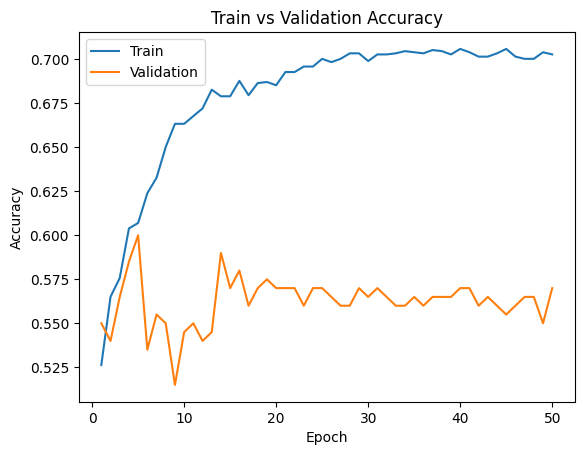

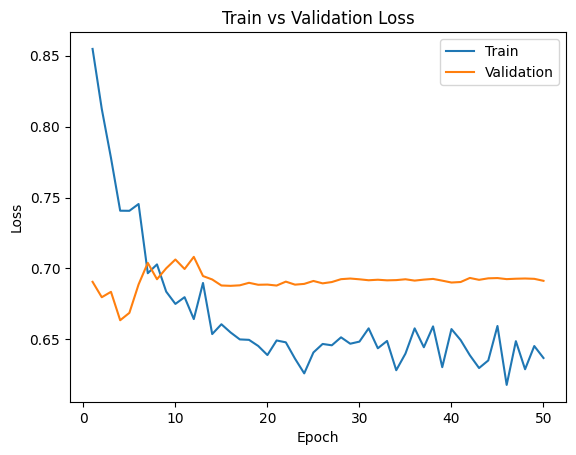

In [34]:
cnn_lstm_model = TakeNet(hidden_size1 = 128, num_layers=1)
cnn_lstm_model.apply(init_weights)  # Apply Xavier Initialization
train(model=cnn_lstm_model, train_loader=train_loader, val_loader=val_loader, num_epochs=50, learning_rate=0.0001)

In [32]:
def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculations
        for inputs, labels in test_loader:
            outputs = model(inputs)
            predicted = torch.round(torch.sigmoid(outputs))  # Binary classification thresholding

            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total * 100
    print(f'Test Accuracy: {accuracy:.2f}%')



In [36]:
evaluate_model(cnn_lstm_model, test_loader)

Test Accuracy: 47.50%
